### A

#### IMPORT

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import random
from stable_baselines3.common.callbacks import CheckpointCallback
from gymnasium import spaces
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
import pyvista as pv
import time
from typing import Dict, Optional, Tuple, Callable, List
import warnings
import os
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import imageio
import io
from PIL import Image
import matplotlib.patches as patches
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
import torch.nn as nn
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from stable_baselines3.common.env_util import make_vec_env
from numba import jit, njit, prange

from neural import GNNMaskablePolicy

#### HELPER

In [2]:
def render_bin_into_plotter(plotter, packed_items, bin_dims, bin_id, offset):
    ox, oy, oz = offset
    bx, by, bz = bin_dims
    
    plotter.add_mesh(pv.Cube(bounds=[ox, ox+bx, oy, oy+by, oz, oz+bz]), 
                     style='wireframe', color='black', line_width=1)
    
    for item in packed_items:
        real_pos = item['real_pos'] 
        dims = item['dims']
        
        item_id = item.get('id', 'N/A')
        order = item.get('delivery_order', 'N/A')
        is_fragile = item.get('fragile', 0)
        
        rx, ry, rz = real_pos
        rl, rw, rh = dims
        
        if is_fragile == 1:
            display_color = "red"
        else:
            display_color = item.get('color', 'skyblue')
            if display_color == "red":
                display_color = "lightgreen"
        
        item_bounds = [
            ox + rx, ox + rx + rl, 
            oy + ry, oy + ry + rw, 
            oz + rz, oz + rz + rh
        ]
        
        plotter.add_mesh(pv.Cube(bounds=item_bounds), 
                         color=display_color, opacity=0.85, show_edges=True)

        label_pos = [
            ox + rx + rl/2, 
            oy + ry + rw/2, 
            oz + rz + rh/2
        ]
        label_text = f"ID:{item_id}\nOrd:{order}"
        
        plotter.add_point_labels(
            [label_pos], 
            [label_text],
            font_size=9,
            text_color="black",
            shape_color="white",
            shape_opacity=0.6,
            always_visible=True
        )

def plot_delivery_routes(all_bins_packed_data, start_point=(0, 0), max_cols=3, combine_all=False):
    n_bins = len(all_bins_packed_data)
    if n_bins == 0:
        print("Tidak ada data bin untuk diplot.")
        return
    
    if combine_all:
        plt.figure(figsize=(12, 9))
        plt.scatter(start_point[0], start_point[1], marker='s', s=250, color='red', 
                    label='DEPOT', zorder=10)
        
        for i, bin_items in enumerate(all_bins_packed_data):
            unique_dests = {}
            for item in bin_items:
                d_id = item['id']
                if d_id not in unique_dests:
                    unique_dests[d_id] = {
                        'x': item['dest_x'], 
                        'y': item['dest_y'], 
                        'order': item['delivery_order']
                    }
            
            sorted_ids = sorted(unique_dests.items(), key=lambda x: x[1]['order'], reverse=True)
            
            rx = [start_point[0]] + [v['x'] for k, v in sorted_ids] + [start_point[0]]
            ry = [start_point[1]] + [v['y'] for k, v in sorted_ids] + [start_point[1]]
            
            line_color = f'C{i}'
            
            plt.plot(rx, ry, '-', alpha=0.7, label=f'Rute Bin {i+1}', linewidth=2.5)
            
            plt.quiver(rx[:-1], ry[:-1], np.diff(rx), np.diff(ry), 
                       scale_units='xy', angles='xy', scale=1, color=line_color, 
                       width=0.004, headwidth=5)
            
            plt.scatter([v['x'] for k, v in sorted_ids], [v['y'] for k, v in sorted_ids], 
                        s=100, edgecolors='black', zorder=5)

        plt.title("Rute Distribusi", fontsize=14)
        plt.xlabel("Koordinat X")
        plt.ylabel("Koordinat Y")
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        cols = min(n_bins, max_cols)
        rows = math.ceil(n_bins / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
        axes_flat = axes.flatten()
        
        for i in range(len(axes_flat)):
            ax = axes_flat[i]
            if i >= n_bins:
                ax.axis('off')
                continue
                
            bin_items = all_bins_packed_data[i]
            unique_dests = {}
            for item in bin_items:
                d_id = item['id']
                if d_id not in unique_dests:
                    unique_dests[d_id] = {
                        'x': item['dest_x'], 
                        'y': item['dest_y'], 
                        'order': item['delivery_order'],
                        'count': 0
                    }
                unique_dests[d_id]['count'] += 1
            
            sorted_ids = sorted(unique_dests.items(), key=lambda x: x[1]['order'], reverse=True)
            
            rx = [start_point[0]] + [v['x'] for k, v in sorted_ids] + [start_point[0]]
            ry = [start_point[1]] + [v['y'] for k, v in sorted_ids] + [start_point[1]]
            
            ax.plot(rx, ry, '--', color='gray', alpha=0.3, zorder=1)
            ax.quiver(rx[:-1], ry[:-1], np.diff(rx), np.diff(ry), 
                       scale_units='xy', angles='xy', scale=1, color=f'C{i}', zorder=2)
            
            ax.scatter(rx[1:-1], ry[1:-1], s=120, color=f'C{i}', edgecolors='black', zorder=3)
            ax.scatter(start_point[0], start_point[1], marker='s', s=150, color='red', label='Depot', zorder=4)
            
            for k, v in unique_dests.items():
                ax.annotate(f"ID:{k}\n({v['count']} pcs)", (v['x'], v['y']), 
                            xytext=(0, 10), textcoords='offset points', 
                            ha='center', fontsize=8, fontweight='bold')
                
            ax.set_title(f"Rute Kendaraan {i+1}", fontsize=12)
            ax.grid(True, alpha=0.2)
            
        plt.suptitle("Rute Distribusi", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

def make_gif(packed_items, bin_dims, bin_number, is_final_step=False):
    fig = plt.figure(figsize=(15, 7), dpi=100) 
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title(f"Bin #{bin_number} | ID: {len(packed_items)}")
    
    L, W, H = bin_dims
    ax1.set_xlim(0, L); ax1.set_ylim(0, W); ax1.set_zlim(0, H)
    
    cmap = plt.get_cmap('viridis')
    
    if len(packed_items) > 0:
        for i, item in enumerate(packed_items):
            py, px, pz = item['real_pos']
            dy, dx, dz = item['dims']
            
            if item.get('fragile', 0) > 0.5:
                color = (1.0, 0.0, 0.0, 0.7) 
                edge_color = 'darkred'
            else:
                color = cmap(i / max(len(packed_items), 1))
                color = (color[0], color[1], color[2], 0.7)
                edge_color = 'black'
                
            ax1.bar3d(py, px, pz, dy, dx, dz, color=color, edgecolor=edge_color, alpha=0.6, antialiased=True, linewidth=0.5)

    ax1.view_init(elev=20, azim=45)

    ax2 = fig.add_subplot(122)
    ax2.set_title("Peta Rute LIFO (P = Destinasi, R = Kembali ke Depot )")
    
    depot_coords = (0, 0)
    depot_size = 4
    
    rect = patches.Rectangle(
        (depot_coords[0] - depot_size/2, depot_coords[1] - depot_size/2), 
        depot_size, depot_size, 
        linewidth=2, edgecolor='black', facecolor='red', zorder=5
    )
    ax2.add_patch(rect)
    ax2.text(depot_coords[0], depot_coords[1] + depot_size, "DEPOT", 
             ha='center', fontweight='bold', color='black', fontsize=9)

    if len(packed_items) > 0:
        dests = np.array([[p['dest_x'], p['dest_y']] for p in packed_items])
        colors = [cmap(i / max(len(packed_items), 1)) for i in range(len(packed_items))]
        edge_colors = ['red' if p.get('fragile', 0) > 0.5 else 'black' for p in packed_items]
        
        ax2.scatter(dests[:, 0], dests[:, 1], c=colors, s=150, 
                    edgecolor=edge_colors, linewidths=2.0, zorder=2)
        
        ax2.scatter(dests[-1, 0], dests[-1, 1], c='yellow', edgecolors='black', s=200, marker='*', zorder=4)

        unique_route_points = []
        for p in dests[::-1]:
            if len(unique_route_points) == 0 or not np.array_equal(p, unique_route_points[-1]):
                unique_route_points.append(p)
        
        route_coords = [np.array(depot_coords)]
        for pt in unique_route_points:
            route_coords.append(pt)
            
        if is_final_step:
            route_coords.append(np.array(depot_coords))
            
        for i in range(len(route_coords) - 1):
            p1, p2 = route_coords[i], route_coords[i+1]
            
            is_returning = is_final_step and (i == len(route_coords) - 2)
            arrow_col = 'red' if is_returning else 'blue'
            arrow_style = "--" if is_returning else "-"
            
            ax2.annotate("", xy=(p2[0], p2[1]), xytext=(p1[0], p1[1]),
                         arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6", 
                                         color=arrow_col, lw=1.5, alpha=0.7, 
                                         linestyle=arrow_style, shrinkA=5, shrinkB=5),
                         zorder=1)

        label_map = {}
        for i, p in enumerate(packed_items):
            coord = (p['dest_x'], p['dest_y'])
            rank = len(packed_items) - i 
            
            if coord not in label_map or rank < label_map[coord]:
                label_map[coord] = rank
        
        for (dx, dy), rank in label_map.items():
            ax2.text(dx + 1.5, dy + 1.5, f"P{rank}", 
                     fontweight='bold', fontsize=10, 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5),
                     zorder=6)
        
        ax2.text(depot_coords[0] + 2.5, depot_coords[1] - 2.5, "R", 
                 fontweight='bold', fontsize=11, color='darkred',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', pad=1),
                 zorder=7)
            
    else:
        ax2.text(0.5, 0.5, "Menunggu Barang...", ha='center')

    ax2.axis('equal') 
    ax2.margins(0.2)
    ax2.grid(True, linestyle=':', alpha=0.6)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    
    img = imageio.v2.imread(buf)[:, :, :3]
    img_pil = Image.fromarray(img)
    img_final = np.array(img_pil.resize((1500, 700))) 
    
    return img_final


#### MAIN

--- Mulai Training dengan 16 Cores ---
Using cuda device
Logging to ./tensorboard_logs/PPO_env_nn_64_12
------------------------------
| time/              |       |
|    fps             | 246   |
|    iterations      | 1     |
|    time_elapsed    | 132   |
|    total_timesteps | 32768 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 208         |
|    iterations           | 2           |
|    time_elapsed         | 313         |
|    total_timesteps      | 65536       |
| train/                  |             |
|    approx_kl            | 0.020297766 |
|    clip_fraction        | 0.227       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.03       |
|    explained_variance   | -0.0376     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00934     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0199     |
|    va

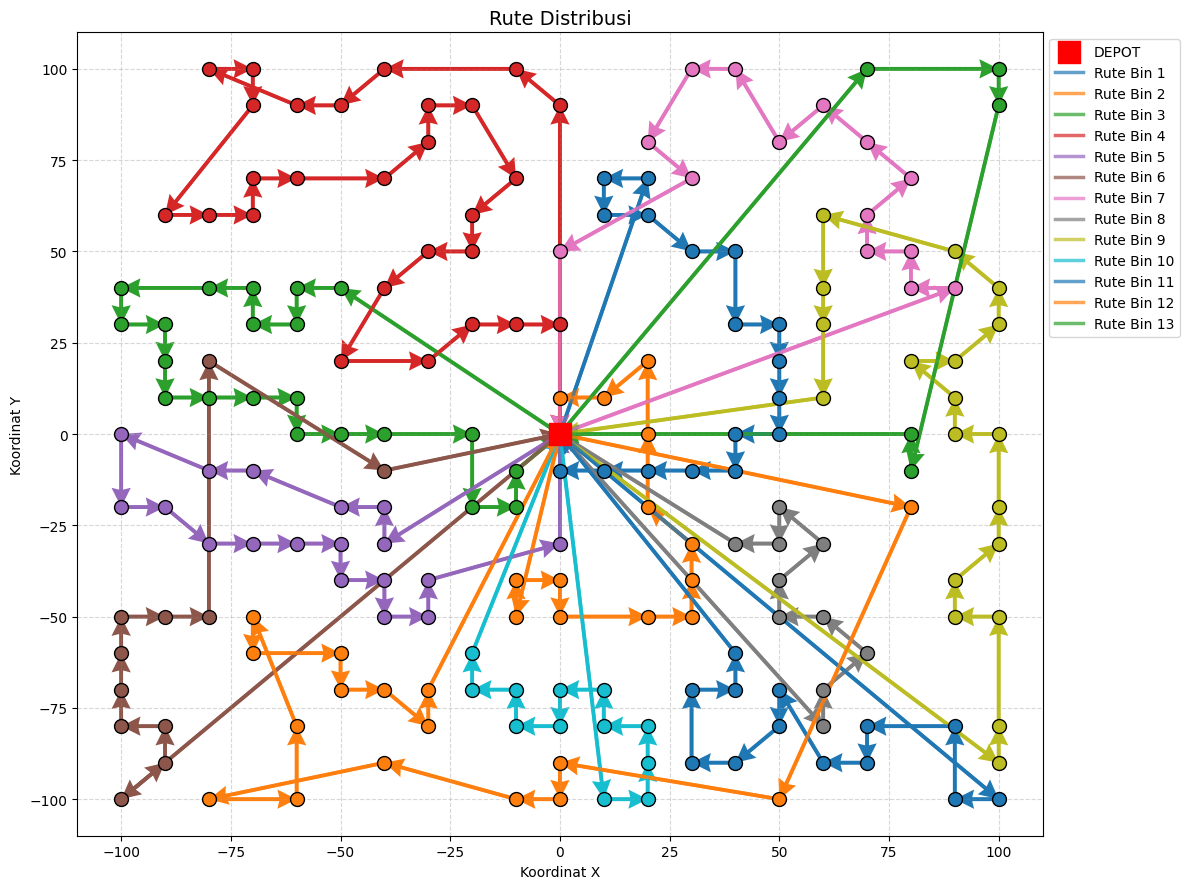

Widget(value='<iframe src="http://localhost:54751/index.html?ui=P_0x28d78c2feb0_0&reconnect=auto" class="pyvis…

In [3]:
%load_ext autoreload
%autoreload 2

def ensure_np(obs):
    clean = {}
    for k, v in obs.items():
        if k == "action_mask":
            continue
        clean[k] = np.array(v, dtype=np.float32)[np.newaxis, ...]
    return clean

def ensure_mask(mask):
    return np.asanyarray(mask, dtype=np.uint8).flatten()

def policy_predict(model, obs_dict, action_mask):
    batched_mask = np.expand_dims(action_mask, axis=0).astype(bool)

    action, _ = model.predict(
        obs_dict, 
        action_masks=batched_mask,
        deterministic=True
    )
    return int(action[0])

def make_env(rank: int, seed: int = 0):
    def _init():
        env = BinPacking3DEnv(
            csv_path=CONFIG["CSV_PATH"],
            bin_dims=CONFIG["BIN_DIMS"],
            max_weight=CONFIG["MAX_WEIGHT"],
            grid_size=CONFIG["GRID_SIZE"],
            support_threshold=CONFIG["SUP_THRES"],
            max_items=CONFIG["MAX_ITEMS"]
        )
        env.reset(seed=seed + rank)
        return env
    return _init

CONFIG = {
    "MAX_ITEMS": 251,
    "MAX_WEIGHT": 500,
    "GRID_SIZE": 64, 
    "BIN_DIMS": (100, 70, 70),
    "N_CORES": 16,
    "TOTAL_TIMESTEPS": 1_000_000,
    "BATCH_SIZE": 256, 
    "LR": 3e-4,
    "SUP_THRES": 0.75,
    "DEPOT_COORDS": (0.0, 0.0),
    "CSV_PATH": '../dataset/sample_training.csv',
    "CHECKPOINT_DIR": "./checkpoints/"
}

if __name__ == "__main__":
    from env_nn import BinPacking3DEnv

    os.makedirs(CONFIG["CHECKPOINT_DIR"], exist_ok=True)

    module_name = BinPacking3DEnv.__module__
    tb_log = f"PPO_{module_name}_{CONFIG['GRID_SIZE']}"

    print(f"--- Mulai Training dengan {CONFIG['N_CORES']} Cores ---")
    
    train_env = SubprocVecEnv([make_env(i) for i in range(CONFIG["N_CORES"])])

    # DEBUG
    # train_env = DummyVecEnv([make_env(i) for i in range(CONFIG["N_CORES"])])

    model = MaskablePPO(
        GNNMaskablePolicy,
        train_env,
        verbose=1,
        n_steps=2048 // CONFIG["N_CORES"] * CONFIG["N_CORES"],
        batch_size=CONFIG["BATCH_SIZE"],
        n_epochs=10,
        gamma=0.99,
        learning_rate=CONFIG["LR"],
        device="cuda" if torch.cuda.is_available() else "cpu",
        tensorboard_log="./tensorboard_logs/"
    )

    current_run_checkpoint_dir = os.path.join(CONFIG["CHECKPOINT_DIR"], f"{module_name}_{CONFIG['GRID_SIZE']}")
    os.makedirs(current_run_checkpoint_dir, exist_ok=True)

    checkpoint_callback = CheckpointCallback(
        save_freq=50000, 
        save_path=current_run_checkpoint_dir,
        name_prefix=f"drl_lcvrp_{module_name}"
    )

    start_time = time.time()
    model.learn(total_timesteps=CONFIG["TOTAL_TIMESTEPS"], callback=checkpoint_callback, tb_log_name=tb_log)
    print(f"Training Selesai. Waktu: {(time.time() - start_time):.2f} detik.")
    
    model.save(f"../website/models/LCVRP_{module_name}_{CONFIG['GRID_SIZE']}")
    
    train_env.close()

    print("\n--- Evaluasi Multi-bin ---")

    global_plotter = pv.Plotter(window_size=[1200, 600])
    global_plotter.set_background("white") 
    bin_offset_vec = np.array([CONFIG["BIN_DIMS"][0] * 1.5, 0, 0], dtype=np.float32)

    eval_env = BinPacking3DEnv(
        csv_path=CONFIG["CSV_PATH"],
        bin_dims=CONFIG["BIN_DIMS"],
        max_weight=CONFIG["MAX_WEIGHT"],
        grid_size=CONFIG["GRID_SIZE"],
        support_threshold=CONFIG["SUP_THRES"],
        max_items=CONFIG["MAX_ITEMS"],
        depot_coords=CONFIG["DEPOT_COORDS"]
    )

    obs, info = eval_env.reset()
    total_real_items = eval_env.num_real_items
    global_availability_mask = eval_env.items_state[:, 0].copy()

    bin_number = 0
    all_bins_packed_data = [] 
    packed_bins_summary = []

    while np.sum(global_availability_mask) > 0.5:
        items_remaining_before = int(np.sum(global_availability_mask))
        bin_number += 1
        
        all_frames = [] 
        
        print(f">>> Bin {bin_number} | Muatan yang Tersisa: {items_remaining_before}")

        obs, _ = eval_env.reset()
        eval_env.items_state[:, 0] = global_availability_mask.copy()
        
        for i in range(eval_env.max_items):
            if eval_env.items_state[i, 0] == 0.0:
                eval_env.items_state[i, 4] = -1.0 

        terminated = False
        while not terminated:
            obs = eval_env._get_obs()
            
            if np.sum(obs['action_mask']) == 0:
                break
                
            action_mask = ensure_mask(obs["action_mask"])
            action = policy_predict(model, ensure_np(obs), action_mask)
            obs, reward, terminated, truncated, info = eval_env.step(action)

            if len(eval_env.packed_items) > 0:
                frame = make_gif(eval_env.packed_items, CONFIG["BIN_DIMS"], bin_number, is_final_step=False)
                all_frames.append(frame)

        final_packed_items = eval_env.finalize_bin() 
        global_availability_mask = eval_env.items_state[:, 0].copy()
        
        final_frame = make_gif(final_packed_items, CONFIG["BIN_DIMS"], bin_number, is_final_step=True)
        for _ in range(8):
            all_frames.append(final_frame)
        
        if len(all_frames) > 0:
            gif_name = f"gifs/result_bin_{bin_number}.gif"
            imageio.mimsave(gif_name, all_frames, fps=2) 
            print(f"Selesai! {gif_name} disimpan.")

        items_remaining_after = int(np.sum(global_availability_mask))
        packed_in_this_bin = items_remaining_before - items_remaining_after
        all_bins_packed_data.append(final_packed_items.copy())
        
        current_offset = bin_offset_vec * (bin_number - 1)
        render_bin_into_plotter(global_plotter, final_packed_items, CONFIG["BIN_DIMS"], bin_number, offset=current_offset)

        packed_bins_summary.append({
            "bin_id": bin_number,
            "packed_count": packed_in_this_bin,
            "vol_ratio": info.get('pack_ratio', 0),
            "weight_util": (eval_env.current_weight / eval_env.max_weight) * 100
        })

    plot_delivery_routes(all_bins_packed_data, combine_all=True)

    global_plotter.show()
    eval_env.close()